# Feature Engineering

In [15]:
import pandas as pd
import numpy as np
import pickle
import warnings
warnings.filterwarnings('ignore')

In [16]:
with open("datas/app_train_merged.pkl", "rb") as f:
    app_train = pickle.load(f)

with open("datas/app_test_merged.pkl", "rb") as f:
    app_test = pickle.load(f)

print(f"app_train : {app_train.shape}")
print(f"app_test  : {app_test.shape}")
print(f"Valeurs manquantes : {app_train.isnull().sum().sum()}")

# Vérification que les corrections sont bien présentes
for col in ['DAYS_EMPLOYED_ANOMALY', 'FLAG_NO_BUREAU', 'FLAG_NO_PREV']:
    print(f"  ✓ {col} présent : {col in app_train.columns}")

app_train : (307507, 142)
app_test  : (48744, 141)
Valeurs manquantes : 0
  ✓ DAYS_EMPLOYED_ANOMALY présent : True
  ✓ FLAG_NO_BUREAU présent : True
  ✓ FLAG_NO_PREV présent : True


In [17]:
for df in [app_train, app_test]:

    # Ratio annuité / revenu (capacité de remboursement mensuelle)
    df['ANNUITY_INCOME_RATIO'] = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL'].replace(0, np.nan)

    # Ratio crédit / revenu (niveau d'endettement global)
    df['CREDIT_INCOME_RATIO'] = df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL'].replace(0, np.nan)

    # Ratio crédit / valeur du bien (LTV proxy)
    df['CREDIT_GOODS_RATIO'] = df['AMT_CREDIT'] / df['AMT_GOODS_PRICE'].replace(0, np.nan)

    # Taux de remboursement annuel (jsaguiar : PAYMENT_RATE)
    df['PAYMENT_RATE'] = df['AMT_ANNUITY'] / df['AMT_CREDIT'].replace(0, np.nan)

    # Revenu par membre du foyer (jsaguiar : INCOME_PER_PERSON)
    df['INCOME_PER_PERSON'] = df['AMT_INCOME_TOTAL'] / df['CNT_FAM_MEMBERS'].replace(0, np.nan)

    # Durée implicite du prêt en années
    df['LOAN_DURATION_YEARS'] = df['AMT_CREDIT'] / df['AMT_ANNUITY'].replace(0, np.nan) / 12

# Remplacement des infinis
for df in [app_train, app_test]:
    df.replace([np.inf, -np.inf], np.nan, inplace=True)

print(f"app_train : {app_train.shape}")
print(f"Nouvelles colonnes : {app_train.shape[1] - 142}")
print(f"Valeurs manquantes : {app_train.isnull().sum().sum()}")

app_train : (307507, 148)
Nouvelles colonnes : 6
Valeurs manquantes : 0


In [18]:
# Tirées de Koehrsen et jsaguiar
for df in [app_train, app_test]:

    # Âge en années (DAYS_BIRTH est négatif par convention)
    df['AGE_YEARS'] = -df['DAYS_BIRTH'] / 365

    # Ancienneté emploi en années
    df['EMPLOYED_YEARS'] = -df['DAYS_EMPLOYED'] / 365

    # Ratio ancienneté emploi / âge (jsaguiar : DAYS_EMPLOYED_PERC)
    # Mesure la stabilité professionnelle relative à l'âge
    df['EMPLOYED_AGE_RATIO'] = df['DAYS_EMPLOYED'] / df['DAYS_BIRTH'].replace(0, np.nan)

    # Ancienneté de la pièce d'identité en années
    # (un ID récent peut signaler un changement de situation)
    df['ID_PUBLISH_YEARS'] = -df['DAYS_ID_PUBLISH'] / 365

    # Ancienneté d'inscription en années
    df['REGISTRATION_YEARS'] = -df['DAYS_REGISTRATION'] / 365

for df in [app_train, app_test]:
    df.replace([np.inf, -np.inf], np.nan, inplace=True)

print(f"app_train : {app_train.shape}")
print(f"Nouvelles colonnes : {app_train.shape[1] - 148}")
print(f"Valeurs manquantes : {app_train.isnull().sum().sum()}")

app_train : (307507, 153)
Nouvelles colonnes : 5
Valeurs manquantes : 0


In [19]:
# EXT_SOURCE_1/2/3 sont les features les plus discriminantes (EDA)
# On crée des combinaisons pour capturer leurs interactions
for df in [app_train, app_test]:

    # Moyenne des 3 scores (synthèse globale)
    df['EXT_SOURCE_MEAN'] = df[['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']].mean(axis=1)

    # Minimum des 3 scores (le maillon faible)
    df['EXT_SOURCE_MIN'] = df[['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']].min(axis=1)

    # Produit des 3 scores (pénalise fortement si l'un est bas)
    df['EXT_SOURCE_PROD'] = df['EXT_SOURCE_1'] * df['EXT_SOURCE_2'] * df['EXT_SOURCE_3']

    # Écart-type (mesure la cohérence entre les 3 scores)
    df['EXT_SOURCE_STD'] = df[['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']].std(axis=1)

for df in [app_train, app_test]:
    df.replace([np.inf, -np.inf], np.nan, inplace=True)

print(f"app_train : {app_train.shape}")
print(f"Nouvelles colonnes : {app_train.shape[1] - 153}")
print(f"Valeurs manquantes : {app_train.isnull().sum().sum()}")

app_train : (307507, 157)
Nouvelles colonnes : 4
Valeurs manquantes : 0


## Nettoyage

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

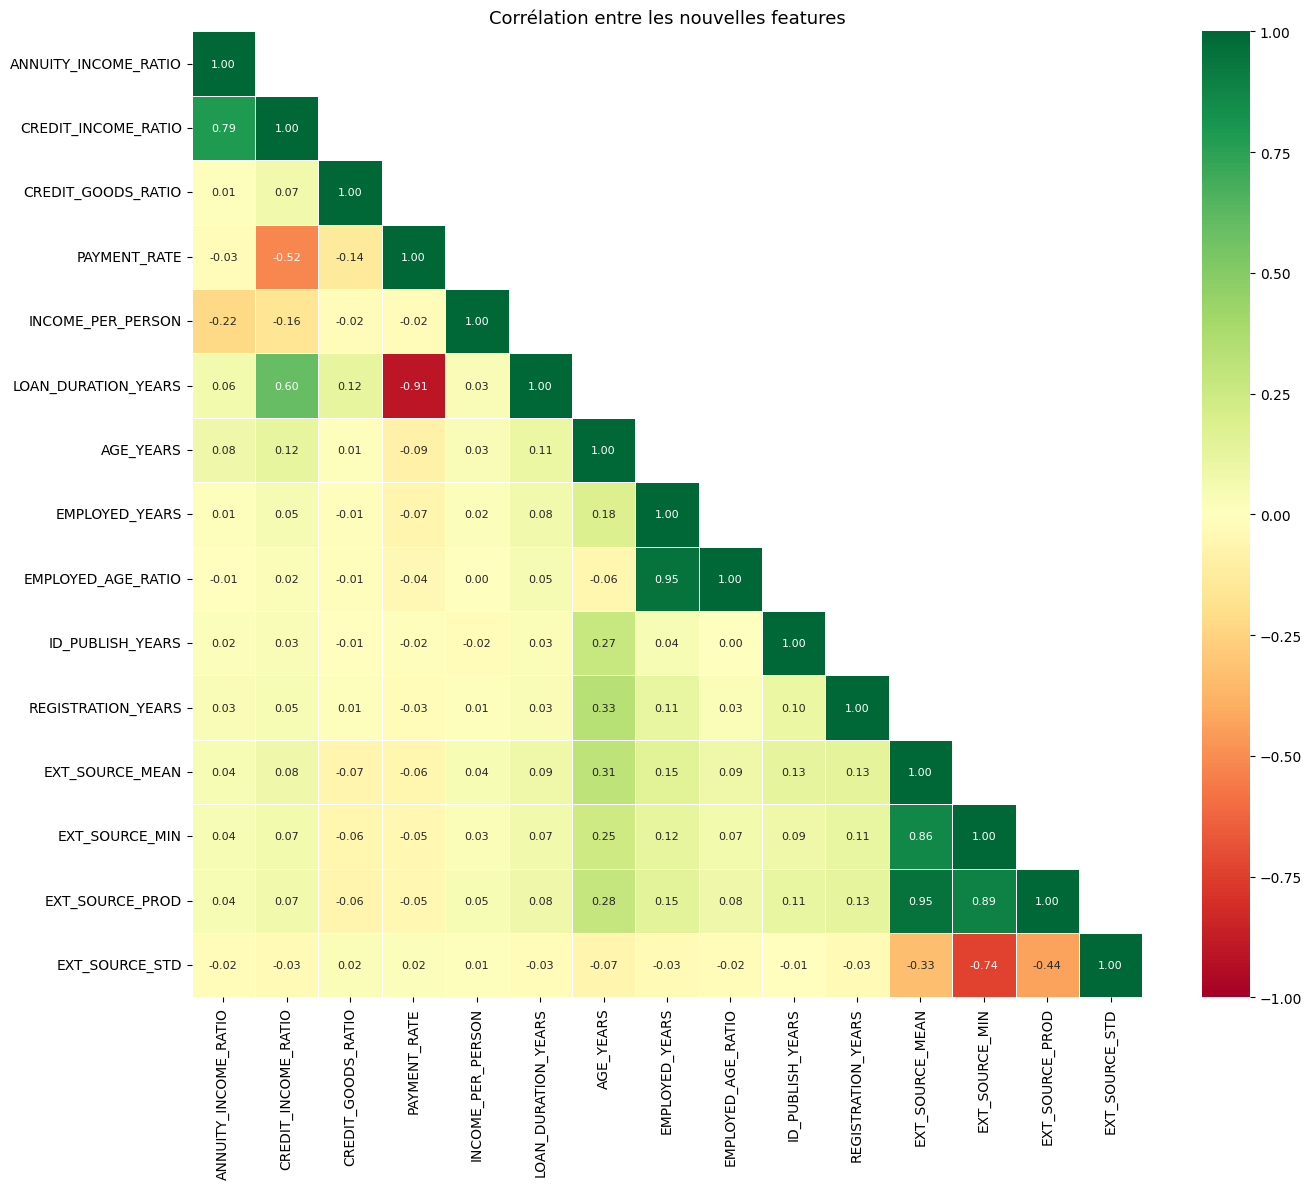

In [32]:
new_features = [
    'ANNUITY_INCOME_RATIO', 'CREDIT_INCOME_RATIO', 'CREDIT_GOODS_RATIO',
    'PAYMENT_RATE', 'INCOME_PER_PERSON', 'LOAN_DURATION_YEARS',
    'AGE_YEARS', 'EMPLOYED_YEARS', 'EMPLOYED_AGE_RATIO',
    'ID_PUBLISH_YEARS', 'REGISTRATION_YEARS',
    'EXT_SOURCE_MEAN', 'EXT_SOURCE_MIN', 'EXT_SOURCE_PROD', 'EXT_SOURCE_STD',
]

corr = app_train[new_features].corr()

# k=-1 exclut la diagonale sans couper la première/dernière ligne
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.5, annot_kws={'size': 8})
ax.set_title("Corrélation entre les nouvelles features", fontsize=13)
plt.tight_layout()
plt.show()

- LOAN_DURATION_YEARS / PAYMENT_RATE : -0.91. Parfait inverse : l'une est mathématiquement l'inverse de l'autre. On garde PAYMENT_RATE (jsaguiar) et on supprime LOAN_DURATION_YEARS.
- EMPLOYED_AGE_RATIO / EMPLOYED_YEARS : 0.95. EMPLOYED_AGE_RATIO est calculé à partir de EMPLOYED_YEARS et AGE_YEARS, qui sont tous deux déjà dans le dataset. Redondance trop forte. On supprime EMPLOYED_AGE_RATIO.
- EXT_SOURCE_PROD / EXT_SOURCE_MEAN : 0.95. Le produit et la moyenne capturent quasi la même chose. On garde EXT_SOURCE_MEAN (plus interprétable) et on supprime EXT_SOURCE_PROD.

In [33]:
cols_to_drop = [
    'LOAN_DURATION_YEARS',   # -0.91 avec PAYMENT_RATE
    'EMPLOYED_AGE_RATIO',    # 0.95 avec EMPLOYED_YEARS
    'EXT_SOURCE_PROD',       # 0.95 avec EXT_SOURCE_MEAN
]

app_train = app_train.drop(columns=cols_to_drop)
app_test  = app_test.drop(columns=cols_to_drop)

print(f"app_train : {app_train.shape}")
print(f"Colonnes supprimées : {len(cols_to_drop)}")

app_train : (307507, 160)
Colonnes supprimées : 3


# Encodage des variables catégorielles

In [34]:
cat_cols = app_train.select_dtypes('object').columns.tolist()
print(f"Nombre de colonnes catégorielles : {len(cat_cols)}\n")
for col in cat_cols:
    print(f"  {col:<35} | {app_train[col].nunique():>2} modalités")

Nombre de colonnes catégorielles : 13

  NAME_CONTRACT_TYPE                  |  2 modalités
  CODE_GENDER                         |  2 modalités
  FLAG_OWN_CAR                        |  2 modalités
  FLAG_OWN_REALTY                     |  2 modalités
  NAME_TYPE_SUITE                     |  7 modalités
  NAME_INCOME_TYPE                    |  8 modalités
  NAME_EDUCATION_TYPE                 |  5 modalités
  NAME_FAMILY_STATUS                  |  6 modalités
  NAME_HOUSING_TYPE                   |  6 modalités
  OCCUPATION_TYPE                     | 19 modalités
  WEEKDAY_APPR_PROCESS_START          |  7 modalités
  ORGANIZATION_TYPE                   | 58 modalités
  EMERGENCYSTATE_MODE                 |  2 modalités


In [35]:
# === Label Encoding des binaires ===
binary_map = {
    'NAME_CONTRACT_TYPE':  {'Cash loans': 0, 'Revolving loans': 1},
    'CODE_GENDER':         {'F': 0, 'M': 1},
    'FLAG_OWN_CAR':        {'N': 0, 'Y': 1},
    'FLAG_OWN_REALTY':     {'N': 0, 'Y': 1},
    'EMERGENCYSTATE_MODE': {'No': 0, 'Yes': 1},
}
for df in [app_train, app_test]:
    for col, mapping in binary_map.items():
        df[col] = df[col].map(mapping)

print("Binaires encodés.")

Binaires encodés.


In [36]:
# === Regroupement ORGANIZATION_TYPE (modalités < 0.5%) ===
freq = app_train['ORGANIZATION_TYPE'].value_counts(normalize=True)
rare_orgs = freq[freq < 0.005].index.tolist()
print(f"\nORGANIZATION_TYPE : {len(rare_orgs)} modalités rares → 'Other'")
for df in [app_train, app_test]:
    df['ORGANIZATION_TYPE'] = df['ORGANIZATION_TYPE'].apply(
        lambda x: 'Other' if x in rare_orgs else x
    )
print(f"Modalités restantes : {app_train['ORGANIZATION_TYPE'].nunique()}")


ORGANIZATION_TYPE : 29 modalités rares → 'Other'
Modalités restantes : 29


In [37]:
# === get_dummies — train et test ensemble pour garantir les mêmes colonnes ===
cat_cols_dummies = [
    'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
    'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'WEEKDAY_APPR_PROCESS_START',
    'OCCUPATION_TYPE', 'ORGANIZATION_TYPE',
]

app_train['_is_train'] = 1
app_test['_is_train']  = 0
combined = pd.concat([app_train, app_test], axis=0, ignore_index=True)
combined = pd.get_dummies(combined, columns=cat_cols_dummies, dummy_na=False)

app_train = combined[combined['_is_train'] == 1].drop(columns='_is_train').reset_index(drop=True)
app_test  = combined[combined['_is_train'] == 0].drop(columns='_is_train').reset_index(drop=True)
app_test  = app_test.drop(columns=['TARGET'], errors='ignore')

print(f"\napp_train : {app_train.shape}")
print(f"app_test  : {app_test.shape}")
print(f"Valeurs manquantes : {app_train.isnull().sum().sum()}")
print(f"Types restants : {app_train.dtypes.value_counts().to_dict()}")


app_train : (307507, 239)
app_test  : (48744, 238)
Valeurs manquantes : 0
Types restants : {dtype('float64'): 102, dtype('bool'): 87, dtype('int64'): 50}


In [38]:
# Conversion des colonnes bool en int (compatibilité sklearn/LightGBM)
for df in [app_train, app_test]:
    bool_cols = df.select_dtypes('bool').columns.tolist()
    df[bool_cols] = df[bool_cols].astype(int)

print(f"Types après conversion : {app_train.dtypes.value_counts().to_dict()}")
print(f"Valeurs manquantes : {app_train.isnull().sum().sum()}")

Types après conversion : {dtype('int64'): 137, dtype('float64'): 102}
Valeurs manquantes : 0


## Nettoyage final

In [46]:
# Calcul de la matrice de corrélation sur toutes les colonnes numériques
# (hors TARGET et SK_ID_CURR)
features = [c for c in app_train.columns if c not in ['TARGET', 'SK_ID_CURR']]
corr_matrix = app_train[features].corr().abs()

# Extraction des paires avec corrélation > 0.90
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={'level_0': 'feature_1', 'level_1': 'feature_2', 0: 'correlation'})
    .query('correlation > 0.70')
    .sort_values('correlation', ascending=False)
)

print(f"Nombre de paires avec corrélation > 0.70 : {len(high_corr_pairs)}\n")
print(high_corr_pairs.to_string(index=False))

Nombre de paires avec corrélation > 0.70 : 83

                           feature_1                                         feature_2  correlation
                       DAYS_EMPLOYED                                    EMPLOYED_YEARS     1.000000
                          DAYS_BIRTH                                         AGE_YEARS     1.000000
                     DAYS_ID_PUBLISH                                  ID_PUBLISH_YEARS     1.000000
               DAYS_EMPLOYED_ANOMALY                             ORGANIZATION_TYPE_XNA     1.000000
                  PREV_REFUSED_COUNT                                     REFUSED_COUNT     1.000000
                   DAYS_REGISTRATION                                REGISTRATION_YEARS     1.000000
                      FLAG_EMP_PHONE                             ORGANIZATION_TYPE_XNA     0.999868
                      FLAG_EMP_PHONE                             DAYS_EMPLOYED_ANOMALY     0.999868
               DAYS_EMPLOYED_ANOMALY                 

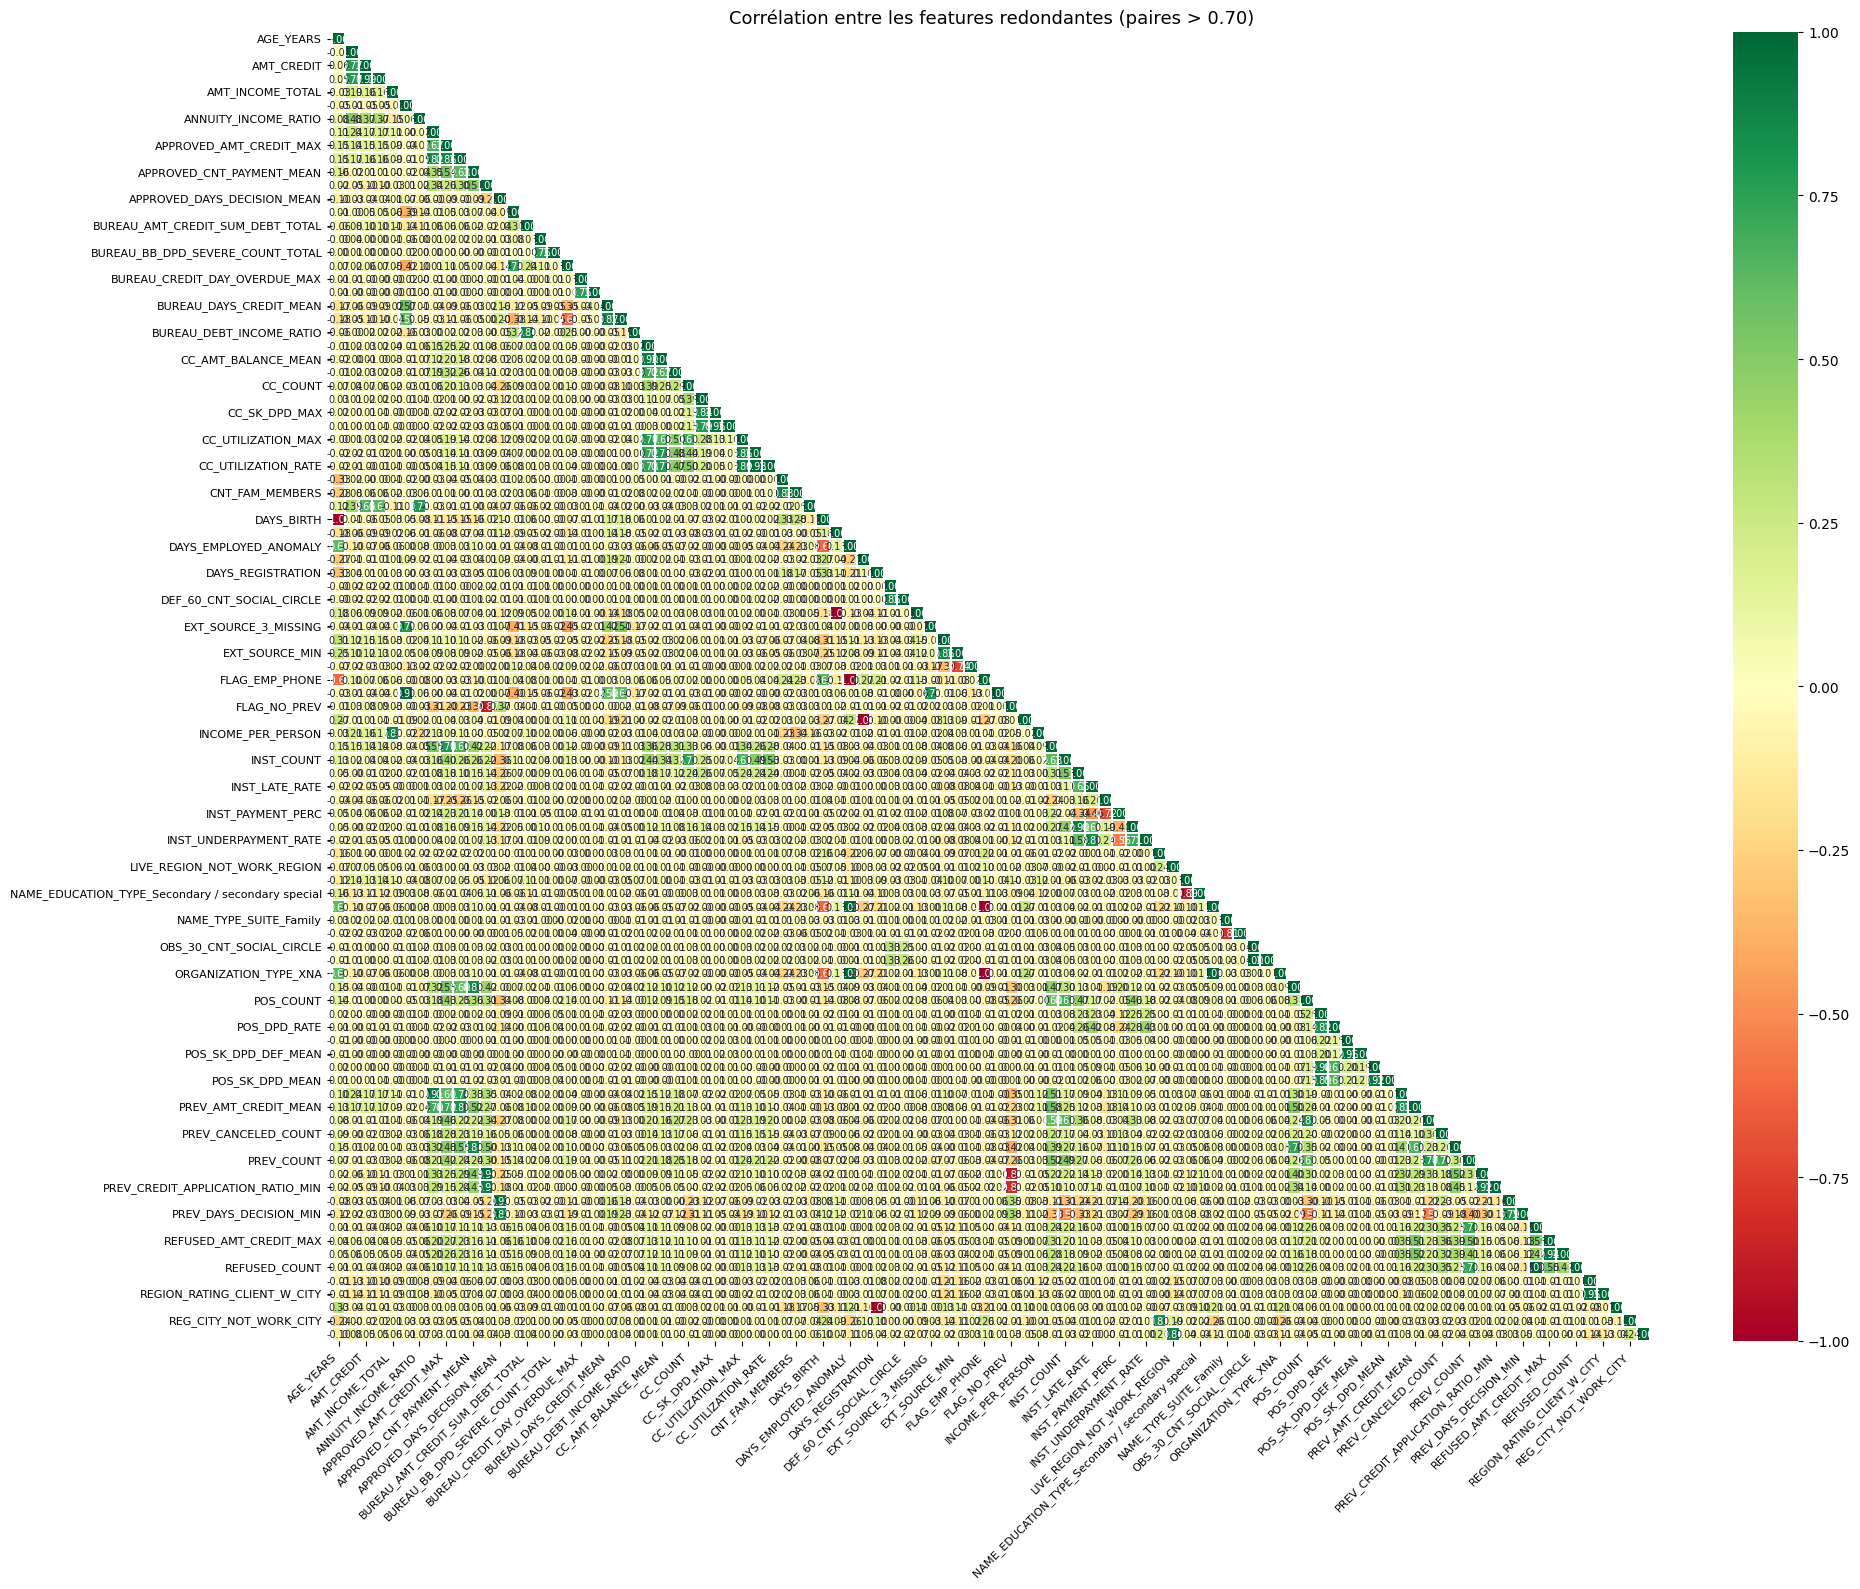

In [47]:
# Colonnes impliquées dans au moins une paire > 0.90
cols_involved = list(set(
    high_corr_pairs['feature_1'].tolist() +
    high_corr_pairs['feature_2'].tolist()
))
cols_involved.sort()

corr_sub = app_train[cols_involved].corr()
mask = np.triu(np.ones_like(corr_sub, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(20, 16))
sns.heatmap(corr_sub, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            ax=ax, linewidths=0.3, annot_kws={'size': 7})
ax.set_title("Corrélation entre les features redondantes (paires > 0.70)", fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

In [48]:
to_delete_column = [
    # corr = 1.00
    "DAYS_BIRTH",           # AGE_YEARS
    "DAYS_EMPLOYED",        # EMPLOYED_YEARS
    "DAYS_ID_PUBLISH",      # ID_PUBLISH_YEARS
    "DAYS_REGISTRATION",    # REGISTRATION_YEARS
    "ORGANIZATION_TYPE_XNA",        # DAYS_EMPLOYED_ANOMALY
    "REFUSED_COUNT",                # PREV_REFUSED_COUNT

    # corr > 0.99
    "FLAG_EMP_PHONE",               # DAYS_EMPLOYED_ANOMALY
    "NAME_INCOME_TYPE_Pensioner",   # DAYS_EMPLOYED_ANOMALY

    # corr > 0.98
    "OBS_60_CNT_SOCIAL_CIRCLE",     # OBS_30_CNT_SOCIAL_CIRCLE
    "CC_UTILIZATION_RATE",          # CC_UTILIZATION_MEAN (qu'on a créée nous-mêmes)

    # corr > 0.96
    "AMT_REQ_CREDIT_BUREAU_MISSING",  # FLAG_NO_BUREAU
    "POS_SK_DPD_DEF_MEAN",            # POS_SK_DPD_DEF_MAX
    "CC_SK_DPD_MEAN",                 # CC_SK_DPD_MAX

    # corr > 0.95
    "APPROVED_CREDIT_APPLICATION_RATIO_MEAN",  # PREV_CREDIT_APPLICATION_RATIO_MEAN
    "REGION_RATING_CLIENT",                    # REGION_RATING_CLIENT_W_CITY

    # corr > 0.90
    "REFUSED_AMT_CREDIT_MAX",         # REFUSED_AMT_CREDIT_MEAN
    "APPROVED_DAYS_DECISION_MEAN",    # PREV_DAYS_DECISION_MEAN
    "POS_SK_DPD_MEAN",                # POS_SK_DPD_MAX
    "PREV_CREDIT_APPLICATION_RATIO_MIN",  # PREV_CREDIT_APPLICATION_RATIO_MEAN
    "APPROVED_AMT_ANNUITY_MEAN",      # PREV_AMT_ANNUITY_MEAN
    "CC_AMT_BALANCE_MAX",             # CC_AMT_BALANCE_MEAN
    #"INST_LATE_PAYMENT_COUNT"         # INST_UNDERPAYMENT_COUNT : on garde les deux car elles mesurent des choses distinctes (retard vs sous-paiement)

    # corr > 0.85
    "POS_DPD_COUNT",              # POS_SK_DPD_MAX
    "CC_UTILIZATION_MAX",         # CC_UTILIZATION_MEAN
    "DEF_60_CNT_SOCIAL_CIRCLE",   # DEF_30_CNT_SOCIAL_CIRCLE
    "LIVE_REGION_NOT_WORK_REGION",# REG_REGION_NOT_WORK_REGION
    "CNT_CHILDREN",               # CNT_FAM_MEMBERS
    "APPROVED_AMT_CREDIT_MEAN",   # PREV_AMT_CREDIT_MEAN
    #"APPROVED_AMT_CREDIT_MAX",    # APPROVED_AMT_CREDIT_MEAN : on vient de la supprimer, donc pas besoin de supprimer celle-ci.

    # corr > 0.80
    "APPROVED_CNT_PAYMENT_MEAN",  # PREV_CNT_PAYMENT_MEAN
    "CC_DPD_COUNT",               # CC_SK_DPD_MAX
    "LIVE_CITY_NOT_WORK_CITY",    # REG_CITY_NOT_WORK_CITY

    # Conservées malgré corrélation > 0.80 :
    # "AMT_CREDIT" / "AMT_GOODS_PRICE" (0.987) : concepts distincts
    # "FLAG_NO_PREV" / "PREV_CREDIT_APPLICATION_RATIO_MEAN" (0.891) : binaire vs continu
    # "EXT_SOURCE_MEAN" / "EXT_SOURCE_MIN" (0.861) : synthèse vs maillon faible
    # "BUREAU_AMT_CREDIT_SUM_DEBT_TOTAL" / "BUREAU_DEBT_INCOME_RATIO" (0.865) : absolu vs normalisé
    # "AMT_INCOME_TOTAL" / "INCOME_PER_PERSON" (0.862) : brut vs par personne
    # "NAME_EDUCATION_TYPE_*" : modalités différentes d'une même variable encodée
]

In [49]:
shape_avant = app_train.shape

app_train = app_train.drop(columns=to_delete_column, errors='ignore')
app_test  = app_test.drop(columns=to_delete_column, errors='ignore')

print(f"Colonnes avant : {shape_avant[1]}")
print(f"Colonnes après : {app_train.shape[1]}")
print(f"Colonnes supprimées : {shape_avant[1] - app_train.shape[1]}")
print(f"Valeurs manquantes : {app_train.isnull().sum().sum()}")

Colonnes avant : 239
Colonnes après : 209
Colonnes supprimées : 30
Valeurs manquantes : 0


In [52]:
#nettoyage des noms des colonnes pour compatibilité avec les modèles
import re

def clean_col_names(df):
    df.columns = [
        re.sub(r'[^A-Za-z0-9_]', '_', col)  # remplace tout caractère spécial par _
        for col in df.columns
    ]
    return df

app_train = clean_col_names(app_train)
app_test  = clean_col_names(app_test)

# Mise à jour de X et FEATURES
FEATURES = [c for c in app_train.columns if c not in ['TARGET', 'SK_ID_CURR']]
X = app_train[FEATURES]

# Vérification
problematic = [c for c in X.columns if re.search(r'[^A-Za-z0-9_]', c)]
print(f"Colonnes avec caractères spéciaux restants : {len(problematic)}")
print(f"X shape : {X.shape}")

Colonnes avec caractères spéciaux restants : 0
X shape : (307507, 207)


In [53]:
# Export
import pickle
with open("datas/app_train_final.pkl", "wb") as f:
    pickle.dump(app_train, f)

with open("datas/app_test_final.pkl", "wb") as f:
    pickle.dump(app_test, f)

print(f"\napp_train exporté : {app_train.shape}")
print(f"app_test  exporté : {app_test.shape}")
print("✓ Export terminé.")


app_train exporté : (307507, 209)
app_test  exporté : (48744, 208)
✓ Export terminé.
